In [6]:
import pandas as pd

# Load the cleaned Netflix dataset
df = pd.read_csv(r"C:\Users\user\Desktop\internship work\TASK 1\netflix_dataset.csv")

# Check the dataset
print(df.shape)
df.head()

(8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min,2021,9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,2021,9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min,2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min,2021,9


### Step 1: Extract Relevant Content Features

Relevant content features were selected from the Netflix dataset to build a basic content-based recommendation system. The selected features are type, director, country, rating, and listed_in because they provide information about the content and can be used to identify similar titles.


In [7]:
# Select relevant features for recommendation
features = ['type', 'director', 'country', 'rating', 'listed_in']

content_df = df[['title'] + features].copy()

# Display the selected features
content_df.head()

,title,type,director,country,rating,listed_in
0,Dick Johnson Is Dead,Movie,Kirsten Johnson,United States,PG-13,Documentaries
1,Ganglands,TV Show,Julien Leclercq,France,TV-MA,"Crime TV Shows, International TV Shows, TV Act..."
2,Midnight Mass,TV Show,Mike Flanagan,United States,TV-MA,"TV Dramas, TV Horror, TV Mysteries"
3,Confessions of an Invisible Girl,Movie,Bruno Garotti,Brazil,TV-PG,"Children & Family Movies, Comedies"
4,Sankofa,Movie,Haile Gerima,United States,TV-MA,"Dramas, Independent Movies, International Movies"


### Step 2: Text Preprocessing

The selected content features are combined into a single text feature. This makes it easier to represent each Netflix title as a collection of descriptive words that can be compared with other titles.

In [8]:
# Fill missing values with empty strings
content_df[features] = content_df[features].fillna('')

# Combine the selected features into one text column
content_df['content_features'] = content_df[features].astype(str).agg(' '.join, axis=1)

# Display the result
content_df[['title', 'content_features']].head()

,title,content_features
0,Dick Johnson Is Dead,Movie Kirsten Johnson United States PG-13 Docu...
1,Ganglands,TV Show Julien Leclercq France TV-MA Crime TV ...
2,Midnight Mass,TV Show Mike Flanagan United States TV-MA TV D...
3,Confessions of an Invisible Girl,Movie Bruno Garotti Brazil TV-PG Children & Fa...
4,Sankofa,"Movie Haile Gerima United States TV-MA Dramas,..."


### Step 3: Calculate Content Similarity

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the combined text features into numerical values. Cosine similarity is then used to measure how similar the Netflix titles are based on their content features.

In [12]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Transform content features into numerical vectors
tfidf_matrix = tfidf.fit_transform(content_df['content_features'])

# Check the shape of the TF-IDF matrix
print(tfidf_matrix.shape)



from sklearn.metrics.pairwise import cosine_similarity

# Select one title for testing
selected_title = "Sankofa"

# Find the index of the selected title
title_index = content_df[content_df['title'] == selected_title].index[0]

# Calculate similarity between the selected title and all other titles
similarity_scores = cosine_similarity(
    tfidf_matrix[title_index],
    tfidf_matrix
).flatten()

# Display the similarity scores
print(similarity_scores.shape)





(8790, 6569)
(8790,)


### Step 4: Generate Recommendations

The recommendation system ranks Netflix titles according to their cosine similarity with the selected title. The titles with the highest similarity scores are recommended as similar content.

In [13]:
# Create a copy of the content dataframe
recommendations = content_df.copy()

# Add similarity scores
recommendations['similarity_score'] = similarity_scores

# Remove the selected title itself
recommendations = recommendations[
    recommendations['title'] != selected_title
]

# Sort titles by similarity score
recommendations = recommendations.sort_values(
    by='similarity_score',
    ascending=False
)

# Display the top 10 recommendations
recommendations[['title', 'type', 'similarity_score']].head(10)

,title,type,similarity_score
1683,Residue,Movie,0.562227
8314,BoJack Horseman Christmas Special: Sabrina's C...,Movie,0.295437
8707,The Darkest Dawn,Movie,0.292372
7807,Adhugo,Movie,0.271955
8009,Pocoyo Halloween: Space Halloween,Movie,0.261802
7496,100 Things to do Before High School,Movie,0.261802
4195,Manson Family Vacation,Movie,0.253342
7196,Seven (Tamil),Movie,0.248321
3093,Taramani,Movie,0.245790
7890,Yeh Hai Bakrapur,Movie,0.242966


### Step 5: Evaluate Recommendation Quality

The recommendation quality is evaluated using the cosine similarity scores of the top recommended titles. Higher similarity scores indicate greater content similarity with the selected title.

In [14]:
# Get the top 10 recommendations
top_10 = recommendations.head(10)

# Calculate the average similarity score
average_similarity = top_10['similarity_score'].mean()

print("Average similarity score:", round(average_similarity, 3))

# Display the top 10 recommendations
top_10[['title', 'type', 'similarity_score']]

Average similarity score: 0.294


,title,type,similarity_score
1683,Residue,Movie,0.562227
8314,BoJack Horseman Christmas Special: Sabrina's C...,Movie,0.295437
8707,The Darkest Dawn,Movie,0.292372
7807,Adhugo,Movie,0.271955
8009,Pocoyo Halloween: Space Halloween,Movie,0.261802
7496,100 Things to do Before High School,Movie,0.261802
4195,Manson Family Vacation,Movie,0.253342
7196,Seven (Tamil),Movie,0.248321
3093,Taramani,Movie,0.245790
7890,Yeh Hai Bakrapur,Movie,0.242966


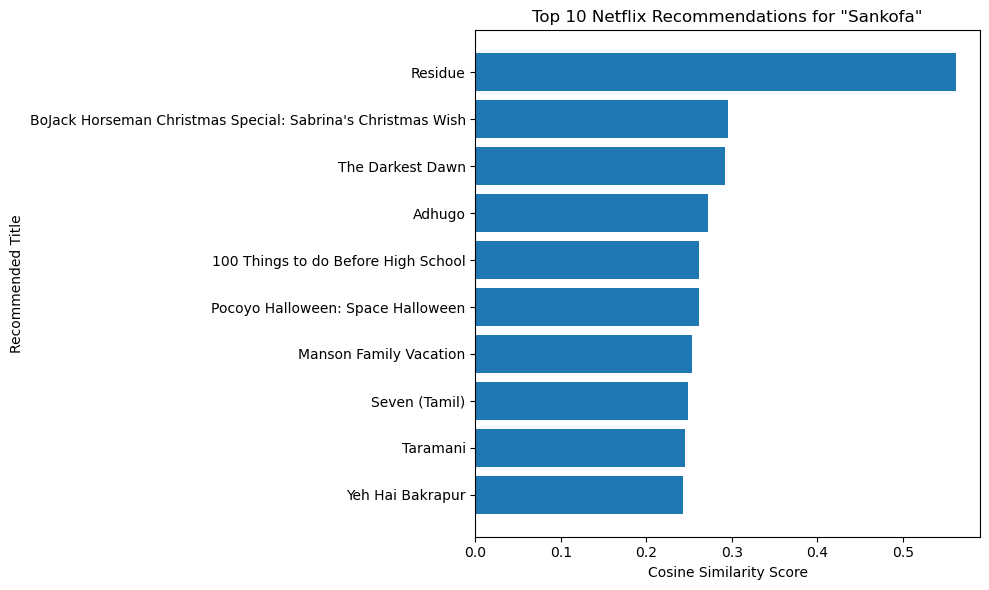

In [15]:
import matplotlib.pyplot as plt

# Prepare top 10 recommendations
top_10 = recommendations.head(10).sort_values(
    by='similarity_score',
    ascending=True
)

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10['title'],
    top_10['similarity_score']
)

plt.xlabel('Cosine Similarity Score')
plt.ylabel('Recommended Title')
plt.title('Top 10 Netflix Recommendations for "Sankofa"')

plt.tight_layout()
plt.show()